**Payments**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from pathlib import Path

In [2]:
file_path = Path.cwd().parent.parent/"Excel"/"5_Payments.xlsx"
df = pd.read_excel(file_path)
df

,Payment_ID,Project_ID,Payment_Date,Amount_Cr,Payment_Status
0,PAY20001,P1001,2026-06-11,13.69,Approved
1,PAY20002,P1001,2026-05-16,12.04,Approved
2,PAY20003,P1001,NaN,6.97,Paid
3,PAY20004,P1001,2026-05-15,6.81,Partially Paid
4,PAY20005,P1001,2026-07-16,1.43,On Hold
...,...,...,...,...,...
1628,PAY21629,P1057,2026-07-29,3.86,NaN
1629,PAY21630,P1167,2023-08-04,14.26,Pending
1630,PAY21631,P1204,2023-05-30,8.61,Approved
1631,PAY21632,P1210,2023-11-25,7.57,Pending


In [3]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1633 entries, 0 to 1632
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Payment_ID      1633 non-null   object 
 1   Project_ID      1609 non-null   object 
 2   Payment_Date    1609 non-null   object 
 3   Amount_Cr       1633 non-null   float64
 4   Payment_Status  1613 non-null   object 
dtypes: float64(1), object(4)
memory usage: 63.9+ KB


In [4]:
df.drop_duplicates(subset=["Payment_ID"], inplace=True)
df["Payment_ID"].isna().sum()

np.int64(0)

In [5]:
df["Payment_Date"] = pd.to_datetime(df["Payment_Date"], errors="coerce")

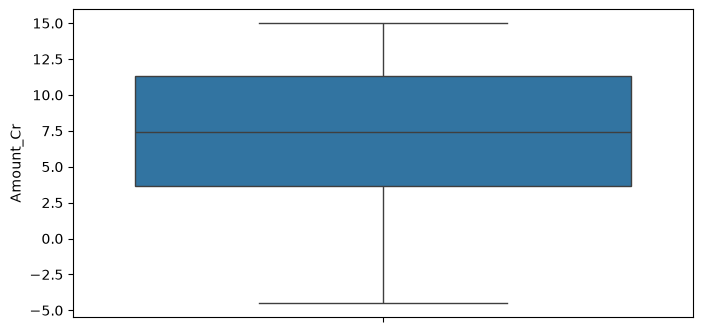

In [6]:
plt.figure(figsize=(8,4))
sb.boxplot(df["Amount_Cr"])
plt.show()

In [7]:
avg_amount = df["Amount_Cr"].mean()
df.loc[df["Amount_Cr"]<0, "Amount_Cr"] = avg_amount

In [8]:
df["Payment_Status"].unique()
df["Payment_Status"] = df["Payment_Status"].replace("Null", np.nan)

In [9]:
df.to_csv("../../Data/Cleaned/Payments.csv", index=False)